# Modelowanie Sekwencji: Od Word2Vec do Kontekstowej Atencji

Witaj na zajęciach praktycznych z Modelowania Sekwencji! W oparciu o wykład, zbadamy, w jaki sposób reprezentujemy dane (od statycznych embeddingów po dynamiczne konteksty) oraz jak ewoluowały architektury do wydajnego przetwarzania układów sekwencyjnych.

## 1. Podsumowanie: Potęga Reprezentacji Ukrytych

Zanim przejdziemy do przetwarzania sekwencji, musimy nauczyć się dobrze reprezentować nasze wejściowe tokeny. Na wykładzie omówiono, jak algorytmy pokroju SVD oraz **Word2Vec** pozwoliły nam odejść od rzadkich i surowych identyfikatorów (one-hot encoding) na rzecz gęstych, semantycznych przestrzeni wektorowych.

W dobrze wyuczonej przestrzeni embeddingów, relacje geometryczne odzwierciedlają relacje semantyczne. Klasycznym tego przykładem jest arytmetyka semantyczna:
$$ \mathbf{w}_{\text{king}} - \mathbf{w}_{\text{man}} + \mathbf{w}_{\text{woman}} \approx \mathbf{w}_{\text{queen}} $$

Co więcej, modele te dziedziczą i odzwierciedlają również uprzedzenia statystyczne (bias) obecne w danych treningowych, co jest bardzo ważną obserwacją. Poniżej zwizualizujemy ten koncept za pomocą modułu `nn.Embedding` z biblioteki PyTorch, konstruując testową, dwuwymiarową przestrzeń wektorową.

Vector for King:  [0.0, 1.0]
Vector for Man:   [0.0, 0.0]
Vector for Woman: [1.0, 0.0]
Resulting Vector: [1.0, 1.0] -> Exactly matches 'Queen' at [1.0, 1.0]!


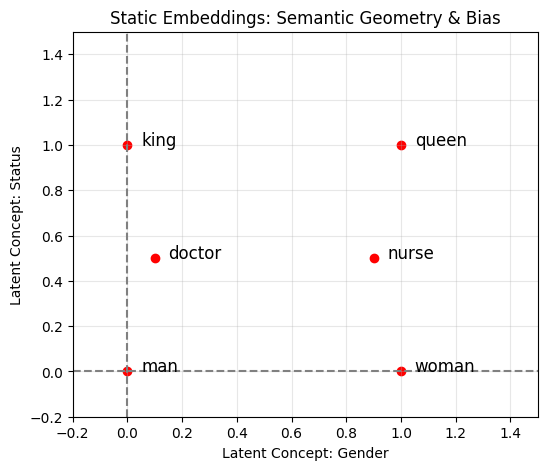

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Define our vocabulary
word_to_idx = {"man": 0, "woman": 1, "king": 2, "queen": 3, "doctor": 4, "nurse": 5}
idx_to_word = {v: k for k, v in word_to_idx.items()}

# 2. Create a PyTorch Embedding layer (static embeddings)
embedder = nn.Embedding(num_embeddings=len(word_to_idx), embedding_dim=2)

# 3. Simulate a trained Word2Vec model's weights
# X-axis represents "Gender" (0.0 = Male, 1.0 = Female)
# Y-axis represents "Status/Royalty"
simulated_weights = torch.tensor([
    [0.0, 0.0],  # man
    [1.0, 0.0],  # woman
    [0.0, 1.0],  # king
    [1.0, 1.0],  # queen
    [0.1, 0.5],  # doctor (reflecting training data bias)
    [0.9, 0.5]   # nurse  (reflecting training data bias)
])
embedder.weight.data = simulated_weights

# Fetch vectors
v_man = embedder(torch.tensor(word_to_idx["man"]))
v_woman = embedder(torch.tensor(word_to_idx["woman"]))
v_king = embedder(torch.tensor(word_to_idx["king"]))

# 4. Perform Semantic Arithmetic: King - Man + Woman
v_result = v_king - v_man + v_woman

print(f"Vector for King:  {v_king.tolist()}")
print(f"Vector for Man:   {v_man.tolist()}")
print(f"Vector for Woman: {v_woman.tolist()}")
print(f"Resulting Vector: {v_result.tolist()} -> Exactly matches 'Queen' at {embedder.weight.data[word_to_idx['queen']].tolist()}!")

# Plotting the geometric space
plt.figure(figsize=(6, 5))
vectors = embedder.weight.data.numpy()
plt.scatter(vectors[:, 0], vectors[:, 1], c='red')

for word, idx in word_to_idx.items():
    plt.annotate(word, (vectors[idx, 0] + 0.05, vectors[idx, 1]), fontsize=12)

plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlim(-0.2, 1.5)
plt.ylim(-0.2, 1.5)
plt.title("Static Embeddings: Semantic Geometry & Bias")
plt.xlabel("Latent Concept: Gender")
plt.ylabel("Latent Concept: Status")
plt.grid(True, alpha=0.3)
plt.show()

## 2. Podejście Rekurencyjne: Pokonanie Wąskiego Gardła Pamięci

Statyczne embeddingi są świetne, ale ignorują słowa w ich otoczeniu. Aby rozumieć cały tekst, potrzebujemy modeli, które potrafią budować i aktualizować reprezentacje krok po kroku. Standardowe sieci RNN cierpią jednak na **problem zanikającego gradientu** (vanishing gradient). Architektura LSTM rozwiązuje ten problem wprowadzając dodatkowy stan komórki ($c_t$) oraz uczące się **bramki**, które decydują o tym, co należy zapomnieć, co nadpisać i co wyrzucić na wyjście.

### Zadanie 1: Zbuduj LSTM od Zera
Twoim zadaniem jest zaimplementowanie klasy `CustomLSTM` całkowicie od zera. Możesz korzystać jedynie z podstawowych operacji na tensorach w PyTorchu oraz prostych warstw jak `nn.Parameter` czy `nn.Linear`. **Zabronione jest używanie wbudowanych `nn.LSTM` oraz `nn.LSTMCell`.**

**Wymagania:**
1. Twoja metoda `__init__` musi przyjmować parametry `input_sz` oraz `hidden_sz` i poprawnie inicjalizować niezbędne wagi oraz biasy (bias).
2. Twoja metoda `forward` ma przyjmować wejściowy tensor `x` o kształcie `[seq_len, batch_size, input_sz]`.
3. Wewnątrz `forward` musisz iterować po kolejnych tokenach sekwencji i aktualizować ukryty stan $h_t$ oraz stan komórki $c_t$ bazując na klasycznych równaniach matematycznych algorytmu LSTM:
   * **Bramka zapominania (forget):** $f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$
   * **Bramka wejściowa (input):** $i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$
   * **Kandydat na nowy stan (candidate):** $\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)$
   * **Bramka wyjściowa (output):** $o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$
   * **Aktualizacje stanów:**
     * $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$
     * $h_t = o_t \odot \tanh(c_t)$
4. Zwróć na koniec jeden tensor, w którym upakowane są wszystkie stany ukryte $h_t$ zebrane po drodze. Oczekiwany kształt: `[seq_len, batch_size, hidden_sz]`.

**Wyzwanie:** Zweryfikujemy poprawność Twojej implementacji ucząc model zadania tzw. odwracania sekwencji (Sequence Reversal). Jeżeli Twoje równania i wagi posiadają usterki w architekturze, funkcja kosztu w ogóle nie zacznie zbiegać.

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomLSTM(nn.Module):
    def __init__(self, input_sz, hidden_sz):
        super().__init__()
        self.hidden_sz = hidden_sz

        self.gates = nn.Linear(input_sz + hidden_sz, 4 * hidden_sz)

    def forward(self, x):
        """
        x shape: [seq_len, batch_size, input_sz]
        """
        seq_len, batch_size, _ = x.size()

        h_t = torch.zeros(batch_size, self.hidden_sz, device=x.device)
        c_t = torch.zeros(batch_size, self.hidden_sz, device=x.device)

        h_states = []


        for t in range(seq_len):
            x_t = x[t]
            combined = torch.cat((x_t, h_t), dim=1)

            gates_out = self.gates(combined)

            i_gate, f_gate, g_gate, o_gate = gates_out.chunk(4, dim=1)

            f_t = torch.sigmoid(f_gate)
            i_t = torch.sigmoid(i_gate)
            c_tilde = torch.tanh(g_gate)
            o_t = torch.sigmoid(o_gate)

            c_t = f_t * c_t + i_t * c_tilde
            h_t = o_t * torch.tanh(c_t)

            h_states.append(h_t)
        return torch.stack(h_states, dim=0)


def train_and_eval_lstm():
    torch.manual_seed(42)
    model = nn.Sequential(CustomLSTM(input_sz=1, hidden_sz=32))
    head = nn.Linear(32, 1)
    optimizer = torch.optim.Adam(list(model.parameters()) + list(head.parameters()), lr=0.01)
    criterion = nn.MSELoss()

    for epoch in range(301):
        data = torch.randn(5, 64, 1)
        target = torch.flip(data, dims=[0])
        optimizer.zero_grad()
        hidden_out = model(data)
        pred = head(hidden_out)
        loss = criterion(pred, target)
        loss.backward()
        optimizer.step()
        if epoch % 100 == 0: print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

    model.eval()
    with torch.no_grad():
        test_seq = torch.tensor([10.0, 20.0, 30.0, 40.0, 50.0]).view(5, 1, 1)
        test_pred = head(model(test_seq)).squeeze()
        print(f"Input: {test_seq.squeeze().tolist()} | Pred: {[round(x,1) for x in test_pred.tolist()]}")

train_and_eval_lstm()

Epoch 0 | Loss: 0.9538
Epoch 100 | Loss: 0.7356
Epoch 200 | Loss: 0.4480
Epoch 300 | Loss: 0.4376
Input: [10.0, 20.0, 30.0, 40.0, 50.0] | Pred: [0.0, 0.3, 0.7, 0.7, 0.6]


## 3. Era Transformera: Maska Przyczynowa i Atencja Multi Head Attention (Causal MHA)

Klasyczne sieci RNN przetwarzają sygnał czysto sekwencyjnie. Transformery omijają to wąskie gardło i przetwarzają całą sekwencję jednocześnie poprzez mechanizm **Self-Attention**.

Istnieje jednak haczyk w przypadku modeli generatywnych do tekstu (jak dekoder w architekturze GPT lub z rodziny LLaMA). Model podczas uczenia się sekwencji nie może "zaglądać w przyszłość", aby ułatwić sobie przewidywanie następnego słowa. Gwarantujemy to dzięki **Masce Przyczynowej** (tzw. Causal Mask) nakładanej na macierz uwagi.

### Zadanie 2: Zbuduj Causal Multi-Head Attention
Twoim zdaniem jest napisanie klasy `CausalMHA` od totalnych podstaw. Bez używania gotowych funkcji takich jak `nn.MultiheadAttention`.

**Wymagania:**
1. Konstruktor `__init__` przyjmuje parametry `d_model` oraz `n_heads`. Zaalokuj tutaj rzutowania liniowe (projekcje), które będą generować macierze Zapytań (Q), Kluczy (K) i Wartości (V), jak również przygotuj finalną warstwę, która rzutuje z powrotem złożony w całość output.
2. Zaimplementuj funkcję `forward(self, x)` przetwarzającą tensor o wymiarach `[batch_size, seq_len, d_model]`.
3. Podziel przestrzeń i wykonaj operację niezależnie dla wielu głów z wykorzystaniem tensorów w kształcie `[B, n_heads, T, d_k]`.
4. Oblicz Przeskalowaną Atencję Iloczynu Skalarnego (Scaled Dot-Product Attention): $\text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V$
5. **Kluczowy krok:** Wewnątrz operacji `forward` musisz nałożyć maskę przyczynową $M$, uniemożliwiając tokenowi o indeksie $i$ uwagę w kierunku tokenu $j$, gdzie $j > i$. (Wskazówka: stwórz dolnotrójkątną macierz za pomocą np. `torch.tril`. W miejscach zamaskowanych wpisz bardzo małą wartość jak `-inf`, jeszcze przed operacją softmax!).
6. Połącz głowy (concatenate), spłaszcz i przekaż dane przez końcową warstwę liniową.

**Wyzwanie:** Nauczymy Twoją implementację prostego algorytmicznego autoregresyjnego zgadywania (przewidywanie f(x) = x+1 w sekwencji). Jeśli Maska Przyczynowa jest uszkodzona i przepuszcza przyszłość – model szybko obniży swój błąd na secie treningowym (oszukując się nawzajem), jednak **całkowicie się zepsuje i polegnie** podczas generacji nowych danych token-po-tokenie!

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class CausalMHA(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0, "d_model musi być podzielne przez n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)

        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, C = x.size()

        q = self.w_q(x) # [B, T, C]
        k = self.w_k(x) # [B, T, C]
        v = self.w_v(x) # [B, T, C]

        q = q.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        attn_scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_k)

        mask = torch.tril(torch.ones(T, T, device=x.device)).view(1, 1, T, T)
        attn_scores = attn_scores.masked_fill(mask == 0, float('-inf'))

        attn_weights = F.softmax(attn_scores, dim=-1)
        out = attn_weights @ v

        out = out.transpose(1, 2).contiguous().view(B, T, C)

        return self.w_o(out)




def train_and_generate_mha():
    torch.manual_seed(42)
    d_model = 32

    try:
        model = nn.Sequential(
            CausalMHA(d_model=d_model, n_heads=4),
            nn.ReLU(),
            nn.Linear(d_model, 1) # Output a single number
        )
    except NotImplementedError as e:
        print(f"Implementation incomplete: {e}")
        return

    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

    print("Training Causal MHA on Autoregressive Counting Task...")
    for epoch in range(501):
        # Input: sequences of ascending numbers, e.g. [4, 5, 6, 7, 8]
        # Target: shifted sequence, e.g. [5, 6, 7, 8, 9]
        x_base = torch.rand(64, 1) * 10
        offsets = torch.arange(10).view(1, 10).float()

        seq = x_base + offsets
        # Broadcating the scalar value to d_model purely as a toy embedding
        x = seq[:, :-1].unsqueeze(-1).expand(-1, -1, d_model)
        targets = seq[:, 1:].unsqueeze(-1)

        optimizer.zero_grad()
        preds = model(x)

        loss = F.mse_loss(preds, targets)
        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch:3d} | Loss: {loss.item():.5f}")

    # --- INFERENCE: GENERATING DATA LIKE GPT ---
    print("\n--- Autoregressive Generation ---")
    model.eval()
    with torch.no_grad():
        # Start with a single "token"
        prompt_val = 5.0
        generated = [prompt_val]
        print(f"Prompt (Seed): {generated}")

        # Generate 5 new numbers token-by-token
        for i in range(5):
            # Prepare context sequence from all generated numbers so far
            context = torch.tensor(generated).float().view(1, -1, 1).expand(-1, -1, d_model)

            # Predict the next step using the full context
            preds = model(context)

            # Extract the prediction for the VERY LAST token in our sequence
            next_val = preds[0, -1, 0].item()
            generated.append(next_val)

        print(f"Final Generated Sequence: {[round(v, 2) for v in generated]}")

train_and_generate_mha()

Training Causal MHA on Autoregressive Counting Task...
Epoch   0 | Loss: 114.91127
Epoch 100 | Loss: 0.06489
Epoch 200 | Loss: 0.03908
Epoch 300 | Loss: 0.01789
Epoch 400 | Loss: 0.00590
Epoch 500 | Loss: 0.00211

--- Autoregressive Generation ---
Prompt (Seed): [5.0]
Final Generated Sequence: [5.0, 5.96, 6.92, 7.86, 8.82, 9.79]
